In [10]:
import numpy as np 
import matplotlib.pyplot as plt
import sys, os
import re
import pandas as pd

import matplotlib as mpl
rc_params = {
    'figure.figsize': (6, 4),
    # 'text.usetex': True,
} 

mpl.rcParams.update(rc_params) 

%load_ext autoreload
%autoreload 2

sys.path.append('..')
from theory.theory import get_ld_z_covariance, get_ld_z_covariance_infty, Etest, get_z_covariation
from theory.utils import parse_config
from tqdm.notebook import tqdm

%matplotlib inline

ROOT_DIR = "/home/remizova/projects/sgf_dyn/results/"
GD_DIR = os.path.join(ROOT_DIR, "GD")
LD_DIR = os.path.join(ROOT_DIR, "LD")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:

get_z_covariation = np.vectorize(get_z_covariation)

In [2]:
def identify_p_vals(res_path):
    # cause when we run code with the same parameters except different values of p,
    # it is overriden
    p_vals = []
    for f_path in os.listdir(res_path):
        res = re.search("^p([0-9]+)_S.npy$", f_path)
        if res is not None:
            p_vals.append(int(res.group(1)))
    p_vals = np.array(sorted(p_vals))
    return p_vals


def load_data(res_path, filenames):
    single = False
    if isinstance(filenames, (str, os.PathLike)):
        single = True
        filenames = [filenames]
    
    res = [
        np.load(os.path.join(res_path, name)) for name in filenames
    ]
    return res[0] if single else res


def swap_time_param_axes(arr_dyn):
    """
    (..., T, p) -> (..., p, T) and vice versa
    """
    return np.swapaxes(arr_dyn, -1, -2)

def data_equal(res_path_1, res_path_2, filenames):
    for name in filenames:
        data_1 = load_data(res_path_1, name)
        data_2 = load_data(res_path_2, name)
        if np.any(data_1 - data_2):
            raise ValueError('Different data used for trainings')
    print('all good!')


def p_S_filename(p):
    return f'p{p}_S.npy'


def p_DYN_betaS_filename(p):
    return f'p{p}_DYN_betaS.npy'

In [3]:
DF_AVG_NAME = 'df_avg.pkl'
# For the results of parameter reprojecting to the space of data samples
DF_AVG_ONLY_DATA_NAME = 'df_avg_only_data.pkl'

# ### DEBUG
# gd_res_folder = "lr1e-03_d1000_n400_snr2e-01_nS20_Nmax1e+06_np50"
# ld_res_folder = "lr1e-03_eps1e-01_d1000_n400_snr2e-01_nS20_nrun1_Nmax1e+06_np50"

# ### d = 100
# gd_res_folder = "lr1e-02_d100_n40_snr2e-01_nS1000_Nmax1e+06_np50"
# ld_res_folder = "lr1e-02_eps1e-01_d100_n40_snr2e-01_nS1000_nrun1_Nmax1e+06_np50"

### d = 1000
gd_res_folder = "lr1e-03_d1000_n400_snr2e-01_nS1000_Nmax1e+06_np50"
ld_res_folder = "lr1e-03_eps1e-01_d1000_n400_snr2e-01_nS1000_nrun1_Nmax1e+06_np50"

gd_res_path = os.path.join(GD_DIR, gd_res_folder)
gd_params = parse_config(os.path.join(gd_res_path, 'data/__parameters.txt'))
gd_p_vals = identify_p_vals(gd_res_path)
df_avg_gd_path = os.path.join(gd_res_path, DF_AVG_NAME)
df_avg_gd_od_path = os.path.join(gd_res_path, DF_AVG_ONLY_DATA_NAME)

ld_res_path = os.path.join(LD_DIR, ld_res_folder)
ld_params = parse_config(os.path.join(ld_res_path, 'data/__parameters.txt'))
ld_p_vals = identify_p_vals(ld_res_path)
df_avg_ld_path = os.path.join(ld_res_path, DF_AVG_NAME)
df_avg_ld_od_path = os.path.join(ld_res_path, DF_AVG_ONLY_DATA_NAME)

IMAGE_DIR = "/home/remizova/projects/sgf_dyn/notebooks/images"

for k, v in gd_params.items():
    if k in ['p', 'pID']:
        continue
    assert ld_params[k] == gd_params[k]

res_path = ld_res_path
params = ld_params

d = params['d']
n = params['n']
psi = d / n
lr = params['lr']
nS = params['nS']
snr = params['snr']
l2 = snr ** 2
epsilon = ld_params['epsilon']

p_vals = np.intersect1d(gd_p_vals, ld_p_vals, assume_unique=True)
alpha_vals = p_vals / n
assert len(p_vals) == len(gd_p_vals) and len(p_vals) == len(ld_p_vals)

DATAGEN_NAMES = [
    f'data/{name}.npy' for name in ['X', 'betastar', 'y', 'beta0', 'plotlist']
]
PVAL_SET_NAMES = [p_S_filename(p) for p in p_vals]

# # validation to make sure we ran algos on correct data and sets
# data_equal(gd_res_path, ld_res_path, DATAGEN_NAMES + PVAL_SET_NAMES)

X, beta_star, y, beta_0, plot_list = load_data(res_path, DATAGEN_NAMES)
betadiff2 = np.linalg.norm(beta_star - beta_0) ** 2
n_time_points = plot_list.shape[0]

In [4]:
T_LABEL = "$t / \\gamma$"
GF_LABEL = "$E^{{GF}}_{{test}}$"
LD_GF_DIFF_LABEL = '$E^{{LD}}_{{test}} - E^{{GF}}_{{test}}$'
SGF_GF_DIFF_LABEL = '$E^{{SGF}}_{{test}} - E^{{GF}}_{{test}}$'



In [5]:
def compute_sample_risk(X, y, S, beta_S):
    """
    X: (n, d)
    y: (n,)
    S: (p,)
    beta_S: (...., p)
    """
    X_S = X[:, S]
    loss = np.mean((y - beta_S @ X_S.T) ** 2, axis=-1) / 2
    return loss


def compute_test_risk(beta_star, S, beta_S, snr=snr):
    """
    beta_star: (d,)
    S: (p,)
    beta_S: (p, T)
    """
    d = beta_star.shape[0]
    res = np.linalg.norm(beta_star[S] - beta_S, axis=-1) ** 2
    mask_S = np.zeros(d, dtype=bool)
    mask_S[S] = True
    res += np.linalg.norm(beta_star[~mask_S]) ** 2 + snr ** 2
    res /= 2
    return res


def compute_test_risk_multirun(beta_star, p_S, beta_S, snr=snr):
    """
    beta_star: (d,)
    p_S: (nS, p)
    beta_S: (nS, p, T)
    snr: scalar
    """

    nS, d = p_S.shape[0], beta_star.shape[0]
    mask_Sc = np.ones((nS, d))
    mask_Sc[np.arange(nS)[:, None], p_S] = 0

    test_error = np.linalg.norm(beta_star[p_S][:, ..., np.newaxis] - beta_S, axis=1) ** 2 + \
                (np.linalg.norm(mask_Sc * beta_star, axis=1) ** 2)[:, None] + \
                snr ** 2
    test_error /= 2
    return test_error


In [6]:
def compute_avg_run_table(p_vals, res_path, plot_list=plot_list,
                        beta_star=beta_star, n=n, use_tqdm=False, only_data_space=True):
    iter_p_vals = enumerate(p_vals)
    if use_tqdm:
        iter_p_vals = tqdm(iter_p_vals)
    
    alphas = np.empty(len(p_vals))
    test_err = np.empty((len(p_vals), len(plot_list)))
    for i_p, p in iter_p_vals:
        alphas[i_p] = int(p) / n
        p_S = load_data(res_path, p_S_filename(p))
        beta_S = load_data(res_path, p_DYN_betaS_filename(p))
        if only_data_space and p > n:
            nS = p_S.shape[0]
            res = np.empty((nS, len(plot_list)))
            for i_S in tqdm(range(nS), leave=False):
                S = p_S[i_S]
                V = np.linalg.svd(X[:, S], full_matrices=False).Vh.T
                beta_S_i_S = beta_S[i_S] @ V @ V.T
                res[i_S] = compute_test_risk(beta_star, S, beta_S_i_S, snr=snr)
        else:
            beta_S = swap_time_param_axes(beta_S)
            res = compute_test_risk_multirun(beta_star, p_S, beta_S)
        test_err[i_p] = res.mean(axis=0)
    
    test_err = pd.DataFrame(data=test_err, index=alphas, columns=plot_list)
    test_err.index.name = 'alpha'
    test_err.columns.name = 'time'
    
    return test_err

# compute all tables 
for res_path, p_vals in zip([gd_res_path, ld_res_path], [gd_p_vals, ld_p_vals]):
    for df_name, only_data_space in zip([DF_AVG_NAME, DF_AVG_ONLY_DATA_NAME], [False, True]):
        # might be changed
        if df_name in os.listdir(res_path):
            continue
        df_avg = compute_avg_run_table(p_vals, res_path, only_data_space=only_data_space, use_tqdm=True)
        df_avg.to_pickle(os.path.join(res_path, df_name))




In [7]:
df_avg_gd = pd.read_pickle(df_avg_gd_path)
df_avg_ld = pd.read_pickle(df_avg_ld_path)
df_avg_gd_od = pd.read_pickle(df_avg_gd_od_path)
df_avg_ld_od = pd.read_pickle(df_avg_ld_od_path)

In [8]:
# ideally, be recomputed, but the code for SGD is not optimized yet
ARCHIVE_DIR = os.path.join(ROOT_DIR, "ICML24_dfs")

test_err_archive_names = {
    100: {
        'gd': 'df_avgGD_d0100.pkl',
        'sgd': 'df_avgSGD_d0100.pkl'
    },
    1000: {
        'gd': 'df_avgGD_1000.pkl',
        'sgd': 'df_avgSGD.pkl'
    }
}

df_names = test_err_archive_names.get(d)
if df_names is not None:
    df_avg_gd_old = pd.read_pickle(os.path.join(ARCHIVE_DIR, df_names['gd']))
    df_avg_sgd_old = pd.read_pickle(os.path.join(ARCHIVE_DIR, df_names['sgd']))

In [9]:
df_diff_ld_gd = df_avg_ld - df_avg_gd
df_diff_ld_gd_od = df_avg_ld_od - df_avg_gd_od
df_diff_sgd_gd = df_avg_sgd_old - df_avg_gd_old

# Figure 5b
Sanity check cause it should be the same as we have shown in ICML 2024 paper

In [10]:
ALPHA_VALS_GD_CHOSEN = [0.2, 0.5, 0.9, 1.1, 1.2, 1.35]
P_VALS_GD_CHOSEN = [int(alpha * n) for alpha in ALPHA_VALS_GD_CHOSEN]
T_VALS_GD = np.logspace(0, 7, 100).astype(int)

gf_etest_th = []
gf_etest_emp = []
for p, alpha in zip(P_VALS_GD_CHOSEN, ALPHA_VALS_GD_CHOSEN):
    gf_etest_emp.append(df_avg_gd.loc[alpha])
    test_err = Etest(alpha, psi, l2, T_VALS_GD * lr, betadiff2) / 2
    gf_etest_th.append(test_err)

/home/remizova/projects/sgf_dyn/notebooks/../theory/theory.py:37: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  exp_val = quad(lambda x: f(x) * _MP_pdf_expression(x, alpha, alpha_minus, alpha_plus),


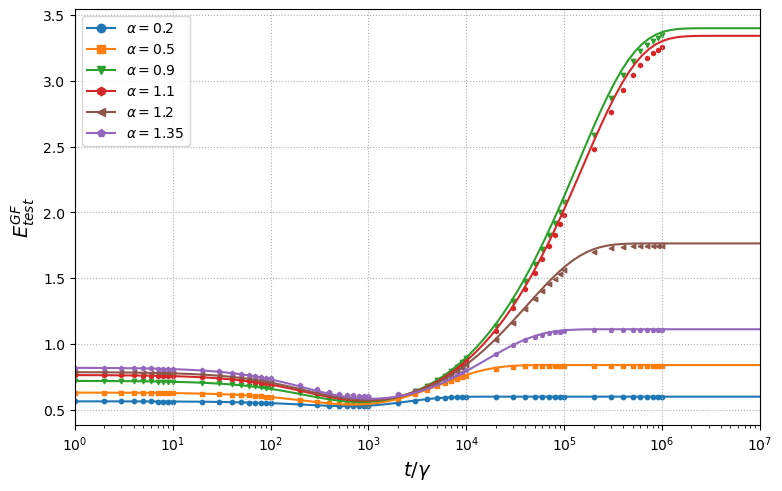

In [11]:
from matplotlib.legend_handler import HandlerLine2D


ALPHA_GD_MARKERS = ["o", "s", "v", "h", "<", "p"]
ALPHA_GD_COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:brown", "tab:purple"]
fig, ax = plt.subplots(figsize=(8.84, 5.4))
for i, p in enumerate(P_VALS_GD_CHOSEN):
    ax.plot(T_VALS_GD, gf_etest_th[i], color=ALPHA_GD_COLORS[i], label=f'$\\alpha={ALPHA_VALS_GD_CHOSEN[i]}$')
    ax.scatter(plot_list, gf_etest_emp[i], marker=ALPHA_GD_MARKERS[i], s=10,
               color=ALPHA_GD_COLORS[i])
ax.set_xscale('log')
ax.set_xlabel(T_LABEL, fontsize=14)
ax.set_xlim(T_VALS_GD.min(), T_VALS_GD.max())
ax.set_ylabel(GF_LABEL, fontsize=14)

dummy_dict = {f'$\\alpha={ALPHA_VALS_GD_CHOSEN[i]}$': ALPHA_GD_MARKERS[i] for i in range(len(ALPHA_VALS_GD_CHOSEN))}

def update_prop(handle, orig):
    handle.update_from(orig)  
    handle.set_marker(dummy_dict[orig.get_label()]) 

ax.legend(handler_map={plt.Line2D:HandlerLine2D(update_func=update_prop)},
          fontsize=10, title_fontsize=12)

ax.grid(ls=':')

fig.savefig(os.path.join(IMAGE_DIR, f'gf_t_{gd_res_folder}.pdf'), bbox_inches='tight')


## Figure 2

In [14]:
ALPHA_VALS_THEORY = np.linspace(0, 1.5, 100)
ALPHA_VALS_THEORY_UNDERP = np.linspace(0, 1, 101)[:-1]

gf_ld_diff_tlim_empirical = df_diff_ld_gd_od.iloc[:, -1]
gf_ld_diff_tlim_theory = epsilon * get_ld_z_covariance_infty(
    ALPHA_VALS_THEORY, only_data_space=True) / (2 * psi)

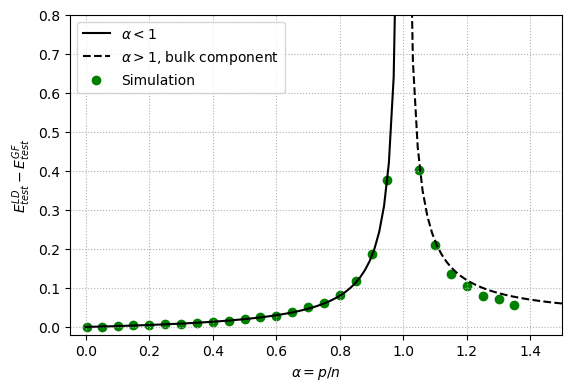

In [15]:
fig, ax = plt.subplots()
mask_underp = ALPHA_VALS_THEORY < 1
mask_overp = ALPHA_VALS_THEORY > 1
ax.plot(ALPHA_VALS_THEORY[mask_underp], gf_ld_diff_tlim_theory[mask_underp], c='black', label='$\\alpha < 1$')
ax.plot(ALPHA_VALS_THEORY[mask_overp], gf_ld_diff_tlim_theory[mask_overp], c='black', ls='--', label='$\\alpha > 1$, bulk component')
ax.scatter(alpha_vals, gf_ld_diff_tlim_empirical, c='green', label='Simulation')
ax.grid(ls=":")
ax.legend()

ax.set_ylim(-0.02, 0.8)
ax.set_xlim(ALPHA_VALS_THEORY.min() - 0.05, ALPHA_VALS_THEORY.max())
ax.set_xlabel('$\\alpha=p / n$')
ax.set_ylabel(LD_GF_DIFF_LABEL)
fig.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
fig.savefig(os.path.join(IMAGE_DIR, f'ld_gf_diff_tlim.pdf')) # bbox_inches='tight')



In [ ]:
sgd_gd_diff_tlim_emp = df_diff_sgd_gd.iloc[:, -1]
# TODO make proper limit formula function!!!
get_z_covariation = np.vectorize(get_z_covariation)
sgd_gd_diff_tlim_th = get_z_covariation(ALPHA_VALS_THEORY, psi, l2, 1000, betadiff2)
# 1 / 4 * ALPHA_VALS_THEORY / psi * ((1 - ALPHA_VALS_THEORY) / psi + snr ** 2) * np.maximum((1 - ALPHA_VALS_THEORY), 0)
sgd_gd_diff_tlim_th[0] = 0
sgd_gd_diff_tlim_th = sgd_gd_diff_tlim_th / psi

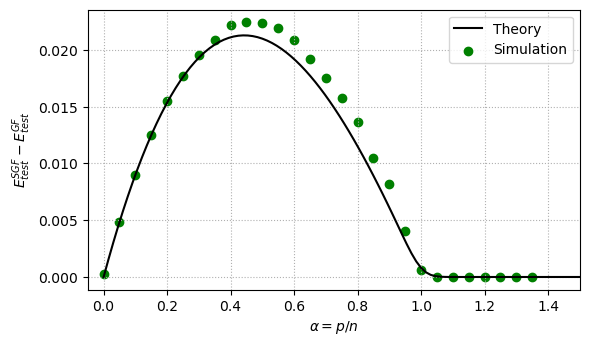

In [79]:
fig, ax = plt.subplots(figsize=(6, 3.5)) 
ax.plot(ALPHA_VALS_THEORY, sgd_gd_diff_tlim_th, c='black', label='Theory') 
ax.scatter(alpha_vals, sgd_gd_diff_tlim_emp, c='green', label='Simulation')
ax.grid(ls=":")
ax.legend()



ax.set_xlim(ALPHA_VALS_THEORY.min() - 0.05, ALPHA_VALS_THEORY.max())
ax.set_xlabel('$\\alpha=p / n$')
ax.set_ylabel(SGF_GF_DIFF_LABEL)
fig.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
fig.savefig(os.path.join(IMAGE_DIR, f'sgf_gf_diff_tlim.pdf')) #, bbox_inches='tight')

## Figure 3

In [85]:

T_VALS_SELECTED = np.logspace(0, 6, 7).astype(int)
T_INDICES_SELECTED = [1, 10, 19, 28, 37, 46, 55]


ld_gf_diff_alpha_emp = []
for t in T_VALS_SELECTED:
    ld_gf_diff_alpha_emp.append(df_diff_ld_gd.loc[:, t])
ld_gf_diff_alpha_th = epsilon * get_ld_z_covariance(
    ALPHA_VALS_THEORY, T_VALS_SELECTED * lr, only_data_space=False).T / (2 * psi)

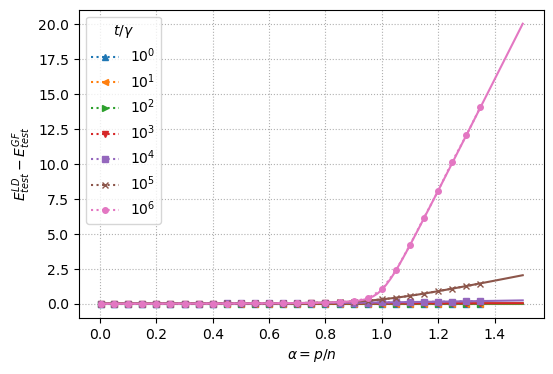

In [87]:
T_MARKERS = ["^", "<", ">", "v", "s", "x", "o"]
fig, ax = plt.subplots()
for i in range(len(T_VALS_SELECTED)):
    line = ax.plot(alpha_vals, ld_gf_diff_alpha_emp[i], ls=':', marker=T_MARKERS[i],
                   markersize=4, label=f'$10^{int(np.log10(T_VALS_SELECTED[i]))}$')
    ax.plot(ALPHA_VALS_THEORY, ld_gf_diff_alpha_th[i],  c=line[0].get_color())

ax.legend(title=T_LABEL)
ax.set_xlabel('$\\alpha=p / n$')
ax.set_ylabel(LD_GF_DIFF_LABEL)
# ax.set_ylim(-0.005, 0.03)
# ax.set_ylim(-0.015, 0.03)
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
# ax.set_yscale('log')
ax.grid(ls=":")
fig.savefig(os.path.join(IMAGE_DIR, f'ld_gf_alpha_{ld_res_folder}.pdf'), bbox_inches='tight')
    

## Figure 6

In [ ]:

sgd_gd_diff_tlim_th = get_z_covariation(ALPHA_VALS_THEORY, psi, l2, 1000, betadiff2)

In [ ]:
ALPHA_VALS_CHOSEN = [0.2, 0.5, 0.9, 1.1, 1.35]

ld_gf_diff_t_emp = []

for alpha in ALPHA_VALS_CHOSEN:
    ld_gf_diff_t_emp.append(df_diff_ld_gd.loc[alpha])
ld_gf_diff_t_emp = np.stack(ld_gf_diff_t_emp)

= epsilon * get_ld_z_covariance(ALPHA_VALS_CHOSEN, plot_list * lr) / (2 * psi)
    

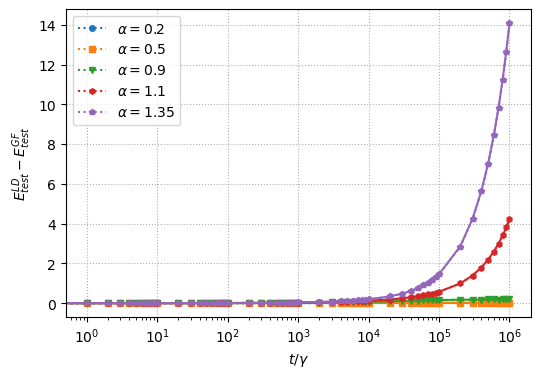

In [ ]:
fig, ax = plt.subplots()

ALPHA_MARKERS = ["o", "s", "v", "h", "p"]
for i in range(len(ALPHA_VALS_CHOSEN)):
    line = ax.plot(plot_list, ld_gf_diff_t_emp[i], ls=':', marker=ALPHA_MARKERS[i],
                   markersize=4, label=f'$\\alpha={ALPHA_VALS_CHOSEN[i]}$')
    ax.plot(plot_list, ld_gf_diff_t_th[i], color=line[0].get_color())

ax.legend()
ax.set_xscale('log')
ax.set_xlabel("$t / \\gamma$")
ax.set_ylabel(LD_GF_DIFF_LABEL)
# ax.set_ylim(-0.005, 0.03)
ax.set_ylim(-0.01, 1)
ax.grid(ls=":")
fig.savefig(os.path.join(IMAGE_DIR, f'ld_gf_diff_t_{ld_res_folder}.pdf'), bbox_inches='tight')

In [113]:
alpha_vals

array([0.0025, 0.05  , 0.1   , 0.15  , 0.2   , 0.25  , 0.3   , 0.35  ,
       0.4   , 0.45  , 0.5   , 0.55  , 0.6   , 0.65  , 0.7   , 0.75  ,
       0.8   , 0.85  , 0.9   , 0.95  , 1.    , 1.05  , 1.1   , 1.15  ,
       1.2   , 1.25  , 1.3   , 1.35  ])

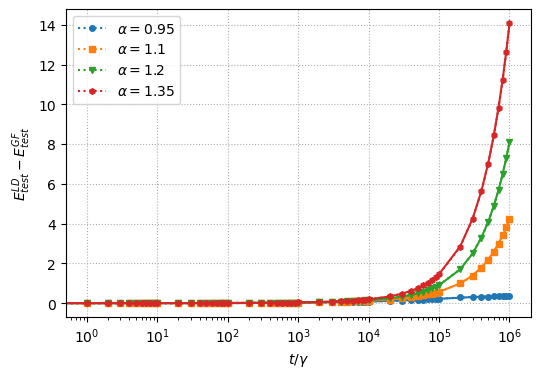

In [115]:
ALPHA_VALS_CHOSEN = [0.95, 1.1, 1.2, 1.35]

ld_gf_diff_t_emp = []
for alpha in ALPHA_VALS_CHOSEN:
    ld_gf_diff_t_emp.append(df_diff_ld_gd.loc[alpha])
ld_gf_diff_t_emp = np.stack(ld_gf_diff_t_emp)

ld_gf_diff_t_th = epsilon * get_ld_z_covariance(ALPHA_VALS_CHOSEN, plot_list * lr) / (2 * psi)

fig, ax = plt.subplots()
 
for i, alpha in enumerate(ALPHA_VALS_CHOSEN):
    line = ax.plot(plot_list, ld_gf_diff_t_emp[i], ls=':', marker=ALPHA_MARKERS[i],
                   markersize=4, label=f'$\\alpha={alpha}$')
    ax.plot(plot_list, ld_gf_diff_t_th[i], color=line[0].get_color())

ax.legend()
ax.set_xscale('log')
ax.set_xlabel("$t / \\gamma$")
ax.set_ylabel(LD_GF_DIFF_LABEL)
# ax.set_ylim(-0.005, 0.03)
# ax.set_ylim(-0.01, 1)
ax.grid(ls=":")
fig.savefig(os.path.join(IMAGE_DIR, f'ld_gf_diff_t_{ld_res_folder}.pdf'), bbox_inches='tight')

In [ ]:
time

array([      0,       1,       2,       3,       4,       5,       6,
             7,       8,       9,      10,      20,      30,      40,
            50,      60,      70,      80,      90,     100,     200,
           300,     400,     500,     600,     700,     800,     900,
          1000,    2000,    3000,    4000,    5000,    6000,    7000,
          8000,    9000,   10000,   20000,   30000,   40000,   50000,
         60000,   70000,   80000,   90000,  100000,  200000,  300000,
        400000,  500000,  600000,  700000,  800000,  900000, 1000000])

In [130]:
alpha_vals

array([0.0025, 0.05  , 0.1   , 0.15  , 0.2   , 0.25  , 0.3   , 0.35  ,
       0.4   , 0.45  , 0.5   , 0.55  , 0.6   , 0.65  , 0.7   , 0.75  ,
       0.8   , 0.85  , 0.9   , 0.95  , 1.    , 1.05  , 1.1   , 1.15  ,
       1.2   , 1.25  , 1.3   , 1.35  ])

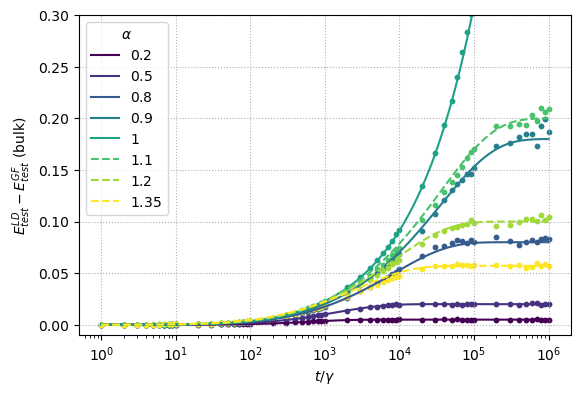

In [ ]:
ALPHA_VALS_CHOSEN = [0.2, 0.5,  0.8, 0.9,1, 1.1, 1.2, 1.35]

ld_gf_od_diff_t_emp = []
for alpha in ALPHA_VALS_CHOSEN:
    ld_gf_od_diff_t_emp.append(df_diff_ld_gd_od.loc[alpha])
ld_gf_od_diff_t_emp = np.stack(ld_gf_od_diff_t_emp)

T_VALS_LD = np.logspace(0, 6, 100).astype(int)
ld_gf_od_diff_t_th = epsilon * get_ld_z_covariance(ALPHA_VALS_CHOSEN, T_VALS_LD * lr, only_data_space=True) / (2 * psi)

fig, ax = plt.subplots()
cmap = plt.get_cmap("viridis")
n_colors = len(ALPHA_VALS_CHOSEN)  # number of trajectories / curves

colors = cmap(np.linspace(0, 1, n_colors))

# ALPHA_MARKERS = ["o", "s", "v", "h", "p"]
for i, alpha in enumerate(ALPHA_VALS_CHOSEN):
    if alpha > 1:
        ls = '--'
    else:
        ls = '-'
    
    line = ax.plot(T_VALS_LD, ld_gf_od_diff_t_th[i], ls=ls,
                   label=f'${alpha}$', c=colors[i])  

    ax.scatter(plot_list, ld_gf_od_diff_t_emp[i], # marker=ALPHA_MARKERS[i],
                s=10,  color=line[0].get_color())
   

ax.legend(title='$\\alpha$')
ax.set_xscale('log')
ax.set_xlabel("$t / \\gamma$")
ax.set_ylabel(LD_GF_DIFF_LABEL + ' (bulk)')
# ax.set_ylim(-0.005, 0.03)
ax.set_ylim(-0.01, 0.3)
ax.grid(ls=":")
fig.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
fig.savefig(os.path.join(IMAGE_DIR, f'ld_gf_diff_t_od.pdf')) # bbox_inches='tight')

In [23]:
ALPHA_VALS_CHOSEN = [0.2, 0.5, 0.8, 0.9, 1, 1.1, 1.2, 1.35]

T_VALS_LD = np.logspace(0, 6, 100).astype(int)

sgf_gf_diff_t_emp = []
sgf_gf_diff_t_th = []
for alpha in ALPHA_VALS_CHOSEN:
    sgf_gf_diff_t_emp.append(df_diff_sgd_gd.loc[alpha])
    sgf_gf_diff_t_th.append(get_z_covariation(alpha, psi, l2, T_VALS_LD * lr, betadiff2))

sgf_gf_diff_t_emp = np.stack(sgf_gf_diff_t_emp)
sgf_gf_diff_t_th = np.stack(sgf_gf_diff_t_th)
# ld_gf_od_diff_t_th = epsilon * get_ld_z_covariance(ALPHA_VALS_CHOSEN, T_VALS_LD * lr, only_data_space=True) / (2 * psi)



/home/remizova/projects/sgf_dyn/notebooks/../theory/theory.py:159: RuntimeWarning: invalid value encountered in scalar divide
  np.exp(- 2 * (1 + alpha) * s) * i1( 4 * np.sqrt(alpha) * s) / s,
/home/remizova/projects/sgf_dyn/notebooks/../theory/theory.py:160: RuntimeWarning: divide by zero encountered in scalar divide
  np.exp(- 2 * (1 - np.sqrt(alpha)) ** 2 * s) /
/home/remizova/projects/sgf_dyn/notebooks/../theory/theory.py:159: RuntimeWarning: invalid value encountered in scalar multiply
  np.exp(- 2 * (1 + alpha) * s) * i1( 4 * np.sqrt(alpha) * s) / s,


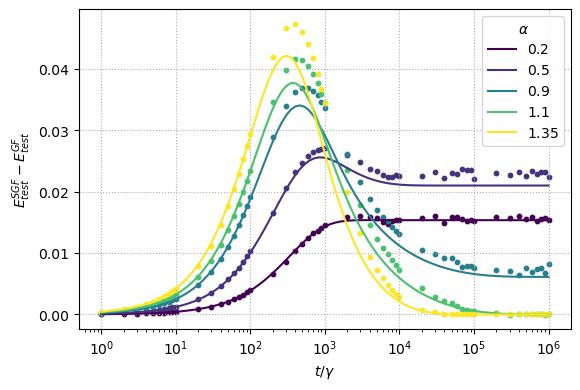

In [26]:
ALPHA_SET = set([0.2, 0.5, 0.9, 1.1, 1.35])

fig, ax = plt.subplots()


cmap = plt.get_cmap("viridis")
n_colors = len(ALPHA_VALS_CHOSEN)  # number of trajectories / curves

colors = cmap(np.linspace(0, 1, n_colors))

# ALPHA_MARKERS = ["o", "s", "v", "h", "p"]
for i, alpha in enumerate(ALPHA_VALS_CHOSEN):
    if alpha in ALPHA_SET:
        line = ax.plot(T_VALS_LD, sgf_gf_diff_t_th[i] / psi, 
                    label=f'${alpha}$', c=colors[i])  

        ax.scatter(plot_list, sgf_gf_diff_t_emp[i], # marker=ALPHA_MARKERS[i],
                    s=10,  color=line[0].get_color())
    

ax.legend(title='$\\alpha$')
ax.set_xscale('log')
ax.set_xlabel("$t / \\gamma$")
ax.set_ylabel(SGF_GF_DIFF_LABEL)
# ax.set_ylim(-0.005, 0.03)
# ax.set_ylim(-0.01, 0.3)
ax.grid(ls=":")
fig.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
fig.savefig(os.path.join(IMAGE_DIR, f'sgf_gf_diff_t.pdf')) # bbox_inches='tight')

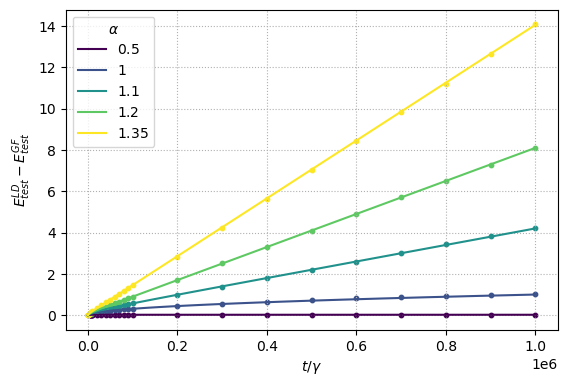

In [27]:
ALPHA_VALS_CHOSEN = [  0.5,  1, 1.1, 1.2, 1.35]

ld_gf_diff_t_emp = []
for alpha in ALPHA_VALS_CHOSEN:
    ld_gf_diff_t_emp.append(df_diff_ld_gd.loc[alpha])
ld_gf_diff_t_emp = np.stack(ld_gf_diff_t_emp)

T_VALS_LD = np.logspace(0, 6, 100).astype(int)
ld_gf_diff_t_th = epsilon * get_ld_z_covariance(ALPHA_VALS_CHOSEN, T_VALS_LD * lr) / (2 * psi)



fig, ax = plt.subplots()


cmap = plt.get_cmap("viridis")
n_colors = len(ALPHA_VALS_CHOSEN)  # number of trajectories / curves

colors = cmap(np.linspace(0, 1, n_colors))

# ALPHA_MARKERS = ["o", "s", "v", "h", "p"]
for i, alpha in enumerate(ALPHA_VALS_CHOSEN):
    
    line = ax.plot(T_VALS_LD, ld_gf_diff_t_th[i], 
                   label=f'${alpha}$', c=colors[i])  

    ax.scatter(plot_list, ld_gf_diff_t_emp[i], # marker=ALPHA_MARKERS[i],
                s=10,  color=line[0].get_color())
   

ax.legend(title='$\\alpha$')
# ax.set_xscale('log')
ax.set_xlabel("$t / \\gamma$")
ax.set_ylabel(LD_GF_DIFF_LABEL)
# ax.set_ylim(-0.005, 0.03)
# ax.set_ylim(-0.01, 1)
ax.grid(ls=":")
fig.subplots_adjust(left=0.15, right=0.97, bottom=0.15, top=0.95)
fig.savefig(os.path.join(IMAGE_DIR, f'ld_gf_diff_t.pdf')) # bbox_inches='tight')

In [104]:
ALPHA_VALS_CHOSEN = [0.2, 0.5, 0.9, 1.1, 1.35]

ld_t_emp = []
for alpha in ALPHA_VALS_CHOSEN:
   ld_t_emp.append(df_avg_ld.loc[alpha])
ld_t_emp = np.stack(ld_t_emp)

ld_t_th = epsilon * get_ld_z_covariance(ALPHA_VALS_CHOSEN, plot_list * lr) / (2 * psi)
for i, alpha in enumerate(ALPHA_VALS_CHOSEN):
    ld_t_th[i] += Etest(alpha, psi, l2, plot_list * lr, betadiff2) / 2

/home/remizova/projects/sgf_dyn/notebooks/../theory/theory.py:37: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  exp_val = quad(lambda x: f(x) * _MP_pdf_expression(x, alpha, alpha_minus, alpha_plus),


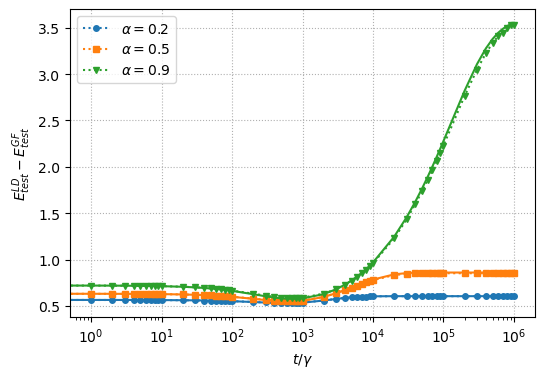

In [106]:
fig, ax = plt.subplots()

ALPHA_MARKERS = ["o", "s", "v", "h", "p"]
for i, alpha in enumerate(ALPHA_VALS_CHOSEN):
    if alpha > 1:
        continue
    line = ax.plot(plot_list, ld_t_emp[i], ls=':', marker=ALPHA_MARKERS[i],
                   markersize=4, label=f'$\\alpha={ALPHA_VALS_CHOSEN[i]}$')
    ax.plot(plot_list, ld_t_th[i], color=line[0].get_color())


ax.legend()
ax.set_xscale('log')
ax.set_xlabel("$t / \\gamma$")
ax.set_ylabel(LD_GF_DIFF_LABEL)
# ax.set_ylim(-0.005, 0.03)
# ax.set_ylim(-0.01, 1)
ax.grid(ls=":")
fig.savefig(os.path.join(IMAGE_DIR, f'ld_t_{ld_res_folder}.pdf'), bbox_inches='tight')